In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 12}

plt.rc('font', **font)
plot_fs = 12

plt.rc('font', family='serif', serif='Times')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)
plt.rc('axes', labelsize=10)
mpl.rcParams['lines.dashed_pattern'] = [2, 2]
mpl.rcParams['lines.linewidth'] = 1.0

import pathlib
cur_dir = pathlib.Path().cwd()
parent_dir = cur_dir.parent

import sys
print(sys.version)
sys.path.append('../')

from models.powertrain.bounded_powertrain import Bounded_powertrain
from models.kinematic.ideal_diff_drive import Ideal_diff_drive
from models.learning.blr_slip import SlipBayesianLinearRegression, FullBodySlipBayesianLinearRegression
from models.learning.blr_slip_acceleration import SlipAccelerationBayesianLinearRegression, FullBodySlipAccelerationBayesianLinearRegression
from models.kinematic.ICR_based import *
from models.kinematic.Perturbed_unicycle import *
from models.kinematic.enhanced_kinematic import *

from util.transform_algebra import *
from util.util_func import *
from data_utils.dataset_parser import *

from NicolasSamson.drive_datasets.utils.acceleration_dataset_analyzer import *
from NicolasSamson.drive_datasets.utils.extractors import * 
import pathlib

import yaml

3.10.12 (main, Jul 19 2024, 11:05:56) [GCC 11.4.0]
3.10.12 (main, Jul 19 2024, 11:05:56) [GCC 11.4.0]
3.10.12 (main, Jul 19 2024, 11:05:56) [GCC 11.4.0]


In [2]:
#Calibration between the arm and the base 
#   Ros 2 pour le bras. 
#   Suport vineta 
#   Suport Matej FOMO
#   Adjustment of the realsense. 
#   The iso can be brought super high ()
#   Binary classification of the hot zone and the cold zone 
#   Bring Grey intensity in the map 
#   Find the origin of the sound  (left or right)
#   Two functionnal rosbags. 
#   In the rosbags : (Surface noramals and the robot orientation).

In [3]:

df_slip = pd.read_pickle("/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/drive_datasets/data/warthog/wheels/gravel/warthog_wheels_gravel_ral2023/model_training_datasets/slip_dataset_all.pkl")

path = "/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/drive_datasets/data/warthog/wheels/gravel/warthog_wheels_gravel_ral2023/config_file_used/_warthog.config.yaml"

print_column_unique_column(df_slip)

['body_vel_disturption_x' 'body_vel_disturption_y'
 'body_vel_disturption_yaw' 'calib_step' 'cmd_left' 'cmd_right'
 'gt_icp_pitch' 'gt_icp_roll' 'gt_icp_x' 'gt_icp_y' 'gt_icp_yaw'
 'gt_icp_z' 'icp_corrected_interpolated_x' 'icp_corrected_interpolated_y'
 'icp_interpolated_x' 'icp_interpolated_y' 'icp_interpolated_yaw'
 'icp_omega' 'icp_pitch' 'icp_roll' 'icp_vel_x' 'icp_vel_y' 'icp_vel_yaw'
 'icp_vx' 'icp_vy' 'icp_x' 'icp_y' 'icp_yaw' 'icp_z' 'idd_vel_x'
 'idd_vel_y' 'idd_vel_yaw' 'imu_acceleration_x' 'imu_acceleration_y'
 'imu_acceleration_z' 'imu_yaw' 'init_icp_pitch' 'init_icp_roll'
 'init_icp_x' 'init_icp_y' 'init_icp_yaw' 'init_icp_z' 'left_wheel_vel'
 'right_wheel_vel' 'steady_state_mask' 'transitory_state_mask'
 'transitory_vel_left' 'transitory_vel_right']


In [4]:

with open(path, 'r') as file:
    config_file_robot = yaml.load(file, Loader=yaml.FullLoader)




In [5]:

df_test = create_dataframe_for_diamond_shape_graph(df_slip,"gravel","warthog","wheels",config_file_robot["/drive/calibration_node"]["ros__parameters"])

NameError: name 'create_dataframe_for_diamond_shape_graph' is not defined

In [6]:
param_gravel = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/ice/ral2023/model_training_datasets/acceleration_dataset.pkl',
    "terrain":"gravel",
    "offline_localisation":True,
    "robot":"warthog",
    "traction":"wheels"
}

param_ice = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/gravel/ral2023/model_training_datasets/acceleration_dataset.pkl',
    "color_background":"lightblue",
    "terrain":"ice",
    "offline_localisation":True,
    "robot":"warthog",
    "traction":"wheels"
}

param_asphalt_1 = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/asphalt/warthog_wheels_asphalt_2024_8_7_10h31s34/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"asphalt",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}

param_asphalt_2 = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/asphalt/warthog_wheels_asphalt_2024_8_7_11h30s30/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"asphalt",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}

param_asphalt_3_focus_on_low_speed = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/asphalt/warthog_wheels_asphalt_2024_8_8_11h46s24/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"asphalt",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}

param_asphalt_4_limitlessss = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/asphalt/warthog_wheels_asphalt_2024_9_20_8h21s48/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"asphalt",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}

param_grass_grand_axe = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/grass/warthog_wheels_grass_2024_9_20_9h9s5/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"grass",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}
param_grass_grand_axe_II = {
    "path_2_dataset":'../NicolasSamson/drive_datasets/warthog/wheels/grass/warthog_wheels_grass_2024_9_20_9h27s52/model_training_datasets/slip_dataset_all.pkl',
    "color_background":"orange",
    "terrain":"grass",
    "offline_localisation":False,
    "robot":"warthog",
    "traction":"wheels"
}



list_params = [param_asphalt_1,param_asphalt_3_focus_on_low_speed,param_asphalt_2,param_asphalt_4_limitlessss, 
            param_gravel,param_ice,param_grass_grand_axe,param_grass_grand_axe_II ] #

In [7]:
df_slip

,init_icp_x,init_icp_y,init_icp_z,init_icp_roll,init_icp_pitch,init_icp_yaw,calib_step,cmd_left_0,cmd_right_0,cmd_left_1,...,body_vel_disturption_yaw_30,body_vel_disturption_yaw_31,body_vel_disturption_yaw_32,body_vel_disturption_yaw_33,body_vel_disturption_yaw_34,body_vel_disturption_yaw_35,body_vel_disturption_yaw_36,body_vel_disturption_yaw_37,body_vel_disturption_yaw_38,body_vel_disturption_yaw_39
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.211815,-10.625767,-12.211815,...,0.289176,0.213872,0.211765,0.249629,0.271360,0.270434,0.331764,0.299221,0.244381,0.239115
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.211815,-10.625767,-12.211815,...,0.202987,0.285324,0.215290,0.159690,0.169383,0.194062,0.280535,0.269249,0.284092,0.238761
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.211815,-10.625767,-12.211815,...,0.179118,0.212520,0.229430,0.233683,0.197028,0.223991,0.220932,0.227201,0.258032,0.242806
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.196089,-5.009836,4.196089,...,-0.979822,-0.969478,-1.014451,-1.035600,-1.095867,-1.133073,-1.092031,-1.114912,-1.121092,-1.118972
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.196089,-5.009836,4.196089,...,-1.182336,-1.158613,-1.172855,-1.157581,-1.135003,-1.136961,-1.136431,-1.102587,-1.112142,-1.080131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,0.0,0.0,0.0,0.0,0.0,0.0,118.0,12.135982,10.679698,12.135982,...,-0.198457,-0.296259,-0.297893,-0.126653,-0.110880,-0.158102,-0.280537,-0.271655,-0.260008,-0.292059
356,0.0,0.0,0.0,0.0,0.0,0.0,118.0,12.135982,10.679698,12.135982,...,-0.268218,-0.211107,-0.146458,-0.136986,0.011666,-0.149200,-0.216527,-0.146146,-0.186675,-0.334774
357,0.0,0.0,0.0,0.0,0.0,0.0,119.0,-0.083888,3.078173,-0.083888,...,0.221084,0.240557,0.258863,0.278558,0.279378,0.291790,0.317679,0.368120,0.350623,0.390421
358,0.0,0.0,0.0,0.0,0.0,0.0,119.0,-0.083888,3.078173,-0.083888,...,0.559187,0.559999,0.563524,0.587745,0.584955,0.576044,0.564076,0.566931,0.561676,0.539535


In [8]:
df_test

,terrain,robot,traction,cmd_left_wheels,cmd_right_wheels,cmd_body_x,cmd_body_yaw,icp_vel_x_smoothed,icp_vel_yaw_smoothed,odom_speed_left_wheels,...,icp_vel_x_time_delay,icp_vel_x_time_constant_problematic_computation,icp_vel_x_time_delay_problematic_computation,icp_vel_x_valid_mask_tc,icp_vel_yaw_gains,icp_vel_yaw_time_constants,icp_vel_yaw_time_delay,icp_vel_yaw_time_constant_problematic_computation,icp_vel_yaw_time_delay_problematic_computation,icp_vel_yaw_valid_mask_tc
0,gravel,warthog,wheels,-12.211815,-10.625767,-3.425637,0.408354,-3.332494,0.193366,-12.059898,...,0.318874,False,False,False,0.450231,0.888531,0.104225,False,False,False
1,gravel,warthog,wheels,4.196089,-5.009836,-0.122062,-2.370217,-0.078660,-1.258607,3.555018,...,0.868727,False,False,False,0.529902,0.983394,0.050069,False,False,False
2,gravel,warthog,wheels,-5.512807,-14.623096,-3.020385,-2.345595,-2.057846,-1.330701,-5.709190,...,0.183330,False,False,False,0.128921,1.745859,1.608538,False,False,False
3,gravel,warthog,wheels,13.527561,14.983485,4.276657,0.374852,3.722516,-0.083733,13.249231,...,0.362993,False,False,False,0.717613,0.501450,0.146186,False,False,False
4,gravel,warthog,wheels,-2.315038,15.302681,1.948146,4.535973,0.637697,2.009060,-0.634536,...,0.334480,False,False,False,0.446049,0.553027,0.144028,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,gravel,warthog,wheels,5.284741,10.692380,2.396568,1.392286,2.174036,0.654951,5.889177,...,0.660126,False,False,False,0.667013,1.012991,0.070625,False,False,False
116,gravel,warthog,wheels,-11.746449,0.939025,-1.621113,3.266085,-0.719621,1.703000,-9.905398,...,0.152037,False,False,False,0.533765,0.579698,0.213597,False,False,False
117,gravel,warthog,wheels,-13.418556,-10.018571,-3.515569,0.875382,-2.831538,0.396747,-13.041864,...,0.197339,False,False,False,1.493806,0.270077,0.111683,False,False,False
118,gravel,warthog,wheels,12.135982,10.679698,3.422352,-0.374944,3.276434,-0.135109,11.759483,...,0.386437,False,False,False,0.654339,0.704484,0.072764,False,False,False


In [9]:
df_all_combined = pd.read_pickle("/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/drive_datasets/results_multiple_terrain_dataframe/all_terrain_diamond_shape_graph_data.pkl")



# Same graph but with many datasets




Note that the yaw angle in the the smooth version is the IMU


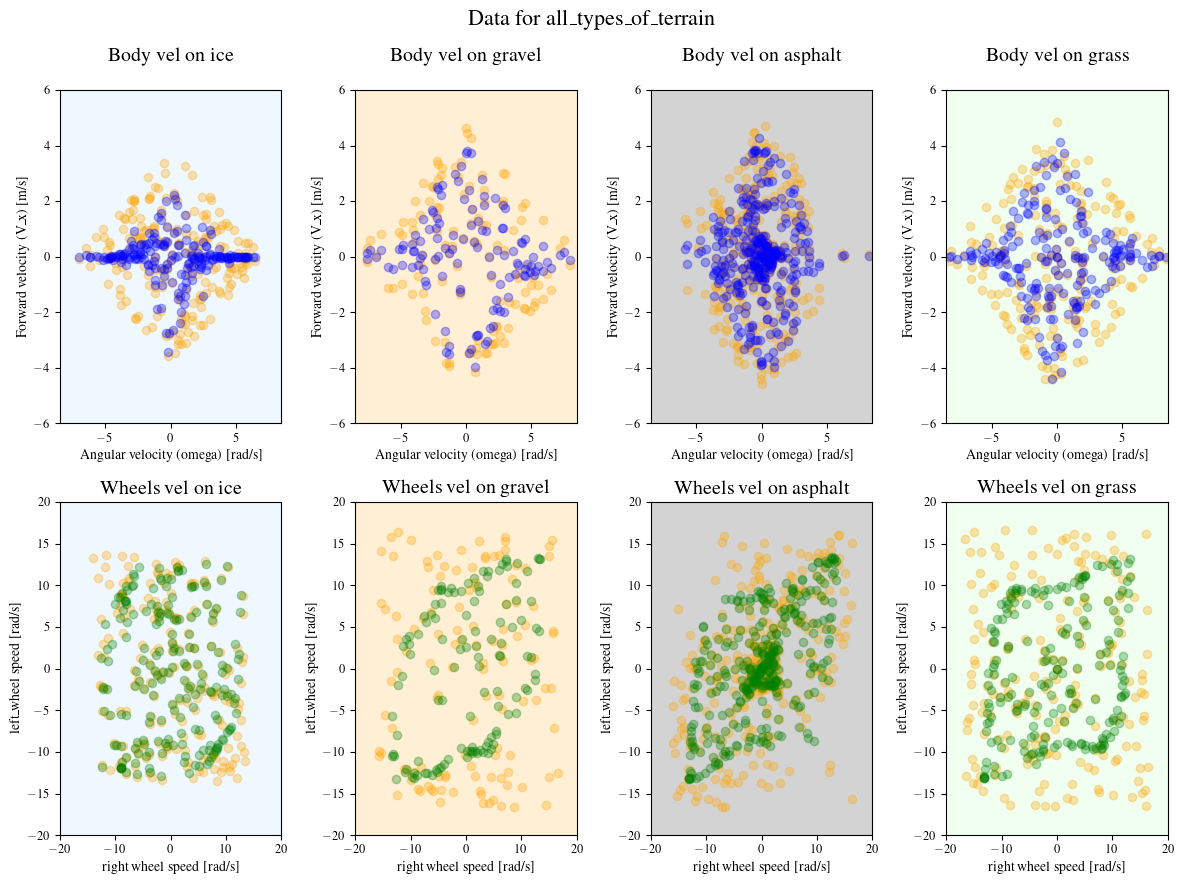

In [10]:


def plot_diamond_graph(df_all_terrain):
    color_dict = {"asphalt":"lightgrey", "ice":"aliceblue","gravel":"papayawhip","grass":"honeydew"}
    list_terrain = df_all_terrain["terrain"].unique()
    size = len(list_terrain)
    fig, axs = plt.subplots(2,size)
    
    f17ig.set_figwidth(3*size)
    fig.set_figheight(3*3)
    alpha_parama= 0.3
    y_lim = 6
    x_lim = 8.5
    
    for i in range(size):  
        terrain = list_terrain[i]
        df = df_all_terrain.loc[df_all_terrain["terrain"]==terrain]        
        axs[0][i].scatter(df["cmd_body_yaw"],df["cmd_body_x"],color = "orange",label='Body vel command',alpha=alpha_parama)
        axs[0][i].scatter(df["cmd_body_yaw"],df["icp_vel_x_smoothed"],color = "blue",label='ICP_smoothed',alpha=alpha_parama) 
        axs[0][i].set_xlabel("Angular velocity (omega) [rad/s]")
        axs[0][i].set_ylabel("Forward velocity (V_x) [m/s]")
        #axs[0][0].legend(loc='center left')
        #axs[0][1].scatter(body_vel[1,:],body_vel[0,:],color = "orange",alpha=alpha_parama)
        #axs[0][1].scatter(raw_icp_vel_yaw_mean,raw_icp_vel_x_mean,color = "grey",label='ICP_raw',alpha=alpha_parama) 
        #axs[0][1].set_xlabel("Angular velocity (omega) [rad/s]")
        #axs[0][1].set_ylabel("Forward velocity (V_x) [m/s]")
        #axs[0][1].legend(loc='center left')

        axs[1][i].scatter(df["cmd_right_wheels"],df["cmd_left_wheels"],color="orange",label="Command",alpha=alpha_parama)
        axs[1][i].scatter(df["odom_speed_right_wheels"],df["odom_speed_left_wheels"],color="green",alpha=alpha_parama)
        axs[1][i].set_ylabel("left_wheel speed [rad/s]")
        axs[1][i].set_xlabel("right wheel speed [rad/s]")
        
        #axs[1][0].legend(loc='upper right')

        axs[0][i].set_title(f"Body vel on {terrain}\n ") # (ICP smooth by spline,yaw=imu)
        #axs[0][1].set_title("Command VS Body vel \n (ICP derivate)")
        axs[1][i].set_title(f"Wheels vel on {terrain}")

        # square plot
        #axs[0][0].axis('equal')
        #axs[0][1].axis('equal')
        wheels_value = 20
        axs[1][i].set_ylim((-wheels_value,wheels_value))
        axs[1][i].set_xlim((-wheels_value,wheels_value))
        
        axs[0][i].set_ylim((-y_lim,y_lim))
        axs[0][i].set_xlim((-x_lim,x_lim))
        #back_ground_color = df.color .unique()
        axs[0][i].set_facecolor(color_dict[terrain])
        axs[1][i].set_facecolor(color_dict[terrain])

        #fig.patches .set_facecolor()
    
    l, legends_label = axs[0][0].get_legend_handles_labels()
    
    l2, legends_label_2 = axs[1][0].get_legend_handles_labels()
    #axs[0][-1].set_axis_off()
    #axs[1][-1].set_axis_off()
    
    legends_labels = legends_label+legends_label_2

    lines = l+l2
    #axs[0][-1].legend(lines, legends_labels, loc = 'center', bbox_to_anchor = (0, -0.55, 1, 1),
    #            bbox_transform = plt.gcf().transFigure,ncol=3)
    fig.suptitle(f"Data for all_types_of_terrain",fontsize=16)

    #fig.patch.set_facecolor(color_background)
    plt.tight_layout()
    

    print('Note that the yaw angle in the the smooth version is the IMU')


plot_diamond_graph(df_all_combi17

In [11]:
def scatter_plot_slip(df,column_x_y_z, ax_to_plot, cmap_name,background_terrain_dict,ylim,xlim,global_cmap,labels_xyz,alpha,show_x_label=False):

    norm_slip = mpl.colors.Normalize(0, vmax=np.abs(global_cmap[1][column_x_y_z[2]].max()))
    norm_slip = mpl.colors.Normalize(0, vmax=2)
   
    if not global_cmap[0]:
        scatter_ax = ax_to_plot.scatter(df[column_x_y_z[0]],df[column_x_y_z[1]],c = np.abs(df[column_x_y_z[2]]),cmap=cmap_name,alpha=alpha)
    else:    
        scatter_ax = ax_to_plot.scatter(df[column_x_y_z[0]],df[column_x_y_z[1]],c = np.abs(df[column_x_y_z[2]]),cmap=cmap_name,norm=norm_slip,alpha=alpha)
    
    if show_x_label:
        ax_to_plot.set_xlabel(labels_xyz[0])  
    ax_to_plot.set_ylabel(labels_xyz[1]) 
    cbar = plt.colorbar(scatter_ax, ax=ax_to_plot)
    cbar.set_label(labels_xyz[2])
    ax_to_plot.set_ylim((-ylim,ylim))
    ax_to_plot.set_xlim((-xlim,xlim))
    ax_to_plot.set_facecolor(mpl.colors.to_rgba(background_terrain_dict,0.3))



# Todo: clim
# Todo: Garder en t[ete quel model est utilise quoi. IMU est filtre 
# Todo: Garder  que les donnes droites. 
# Todo: Potentiellement tester que les vitessses de rotations. 


Note that the yaw angle in the the smooth version is the IMU


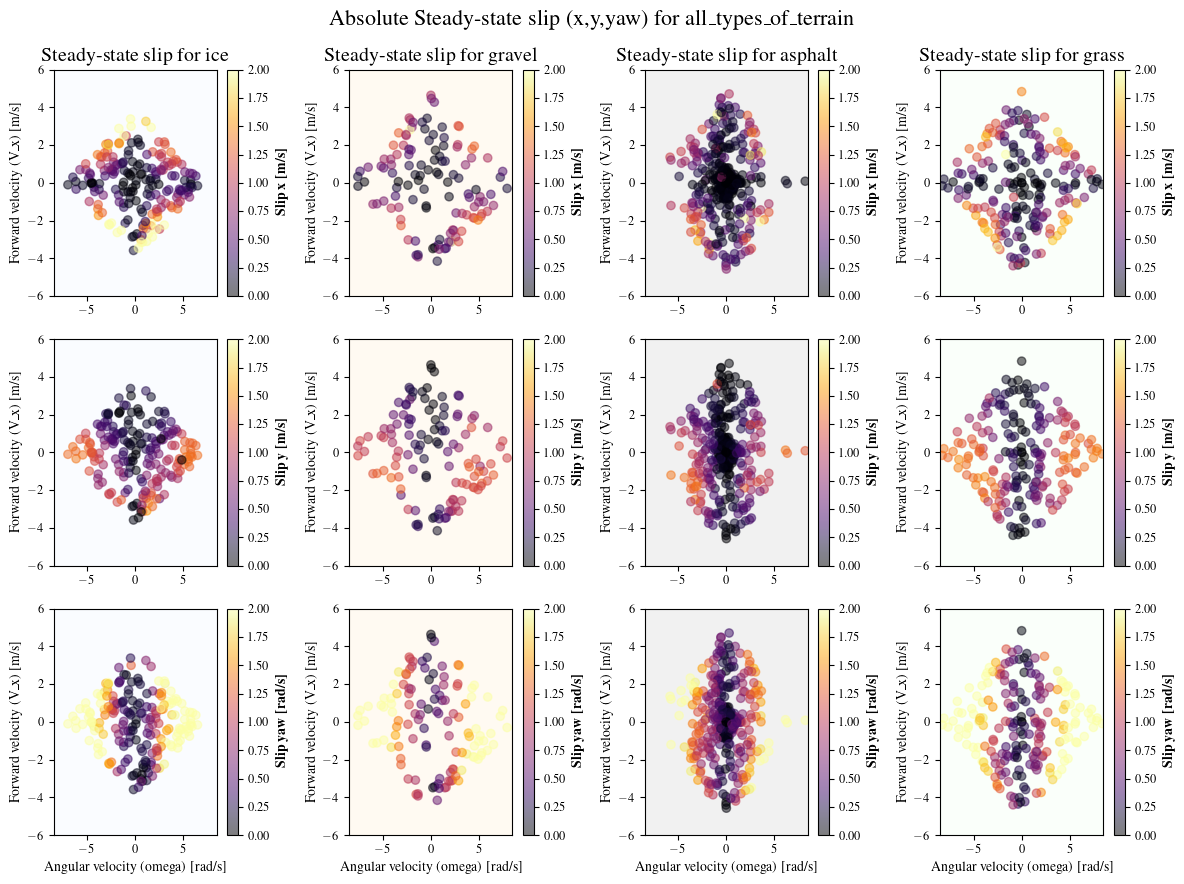

In [12]:
def plot_diamond_graph_slip_heat_map(df_all_terrain,global_cmap = True):
    color_dict = {"asphalt":"lightgrey", "ice":"aliceblue","gravel":"papayawhip","grass":"honeydew"}
    list_terrain = df_all_terrain["terrain"].unique()
    size = len(list_terrain)
    fig, axs = plt.subplots(3,size)
    
    fig.set_figwidth(3*size)
    fig.set_figheight(3*3)
    alpha_parama= 0.3

    y_lim = 6 # m/s
    x_lim = 8.5 #m/s
    cmap = 'viridis' # 
    norm_slip_yaw = mpl.colors.Normalize(0, vmax=df_all_terrain["slip_body_yaw_ss"].max())

    norm_slip_wheel = mpl.colors.Normalize(0, 0)

    scatter_colored_plot_slip_x = []
    scatter_colored_plot_slip_yaw = []  

    global_cmap = [global_cmap,df_all_combined]
    
    alpha_scatter = 0.5
    
    for i in range(size):  
        terrain = list_terrain[i]
        
        df = df_all_terrain.loc[df_all_terrain["terrain"]==terrain]
        
        labels_xyz  = ["Angular velocity (omega) [rad/s]" , "Forward velocity (V_x) [m/s]",""] 
        column_x_y_z = ["cmd_body_yaw","cmd_body_x", "slip_body_x_ss"]
        show_x_label = False
        #### Slip x 
        if size == 1:
            ax_to_plot = axs[0]
        else:
            ax_to_plot = axs[0,i]
        
        labels_xyz[2] = r"$\textbf{Slip x [m/s]}$"
        scatter_plot_slip(df, column_x_y_z, ax_to_plot, "inferno", color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
       
        ##### Slip y 
        
        column_x_y_z[2] = "slip_body_y_ss"

        if size == 1:
            ax_to_plot = axs[1]
        else:
            ax_to_plot = axs[1,i]
        labels_xyz[2] = r"$\textbf{Slip y [m/s]}$"
        ######### slip y  ####################
        scatter_plot_slip(df,column_x_y_z, ax_to_plot, "inferno",color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
        


        ### Slip yaw 
        column_x_y_z[2] = "slip_body_yaw_ss"
        show_x_label = True
        if size == 1:
            ax_to_plot = axs[2]
        else:
            ax_to_plot = axs[2,i]
        ######### slip y  ####################
        labels_xyz[2] = r"$\textbf{Slip yaw [rad/s]}$"
        scatter_plot_slip(df,column_x_y_z, ax_to_plot, "inferno",color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
        

        axs[0][i].set_title(f"Steady-state slip for {terrain}") # (ICP smooth by spline,yaw=imu)
        

        #if not global_cmap:
        #    scatter_colored_plot_slip_yaw.append(axs[2][i].scatter(df["cmd_body_yaw"],df["cmd_body_x"],c = np.abs(df["slip_body_yaw_ss"]),cmap="viridis",alpha=0.2))
        #else:    
        #    scatter_colored_plot_slip_yaw.append(axs[2][i].scatter(df["cmd_body_yaw"],df["cmd_body_x"],c = np.abs(df["slip_body_yaw_ss"]),cmap="viridis",norm=norm_slip_yaw,alpha=0.2))
        #axs[2][i].set_xlabel("Angular velocity (omega) [rad/s]")
        #axs[2][i].set_ylabel("Forward velocity (V_x) [m/s]")
        #cbar = plt.colorbar(scatter_colored_plot_slip_yaw[i], ax=axs[2, i])
        #cbar.set_label('Yaw slip')
        #axs[2][i].set_ylim((-y_lim,y_lim))
        #axs[2][i].set_xlim((-x_lim,x_lim))
        #axs[2][i].set_facecolor(color_dict[terrain])


        #axs[1][i].set_xlabel("Angular velocity (omega) [rad/s]")
        #axs[1][i].set_ylabel("Forward velocity (V_x) [m/s]")
        #cbar1 = plt.colorbar(scatter_colored_plot_slip_yaw[i], ax=axs[1, i])
        #cbar1.set_label('Yaw slip')
        #axs[1][i].set_title(f"Wheels slip {terrain}")
        #wheels_value = 20
        #axs[1][i].set_ylim((-wheels_value,wheels_value))
        #axs[1][i].set_xlim((-wheels_value,wheels_value))
        
        

        #fig.patches .set_facecolor()
        

    l, legends_label = axs[0][0].get_legend_handles_labels()
    
    l2, legends_label_2 = axs[1][0].get_legend_handles_labels()
    #axs[0][-1].set_axis_off()
    #axs[1][-1].set_axis_off()
    
    legends_labels = legends_label+legends_label_2

    
    lines = l+l2
    #axs[0][-1].legend(lines, legends_labels, loc = 'center', bbox_to_anchor = (0, -0.55, 1, 1),
    #            bbox_transform = plt.gcf().transFigure,ncol=3)
    fig.suptitle(f"Absolute Steady-state slip (x,y,yaw) for all_types_of_terrain",fontsize=16)

    #fig.patch.set_facecolor(color_background)
    
    fig.tight_layout()

    print('Note that the yaw angle in the the smooth version is the IMU')



plot_diamond_graph_slip_heat_map(df_all_combined,global_cmap=True)

# TODO une saturation par ligne. 
# TODO Histogram de l'imu.
# TODO Histrogramme de acceleration, c\etait pour voir les limites logicielles de vitesse. 
# TODO Ratio des constantes de temps 
# TODO Outils de caracterisation. 



Note that the yaw angle in the the smooth version is the IMU


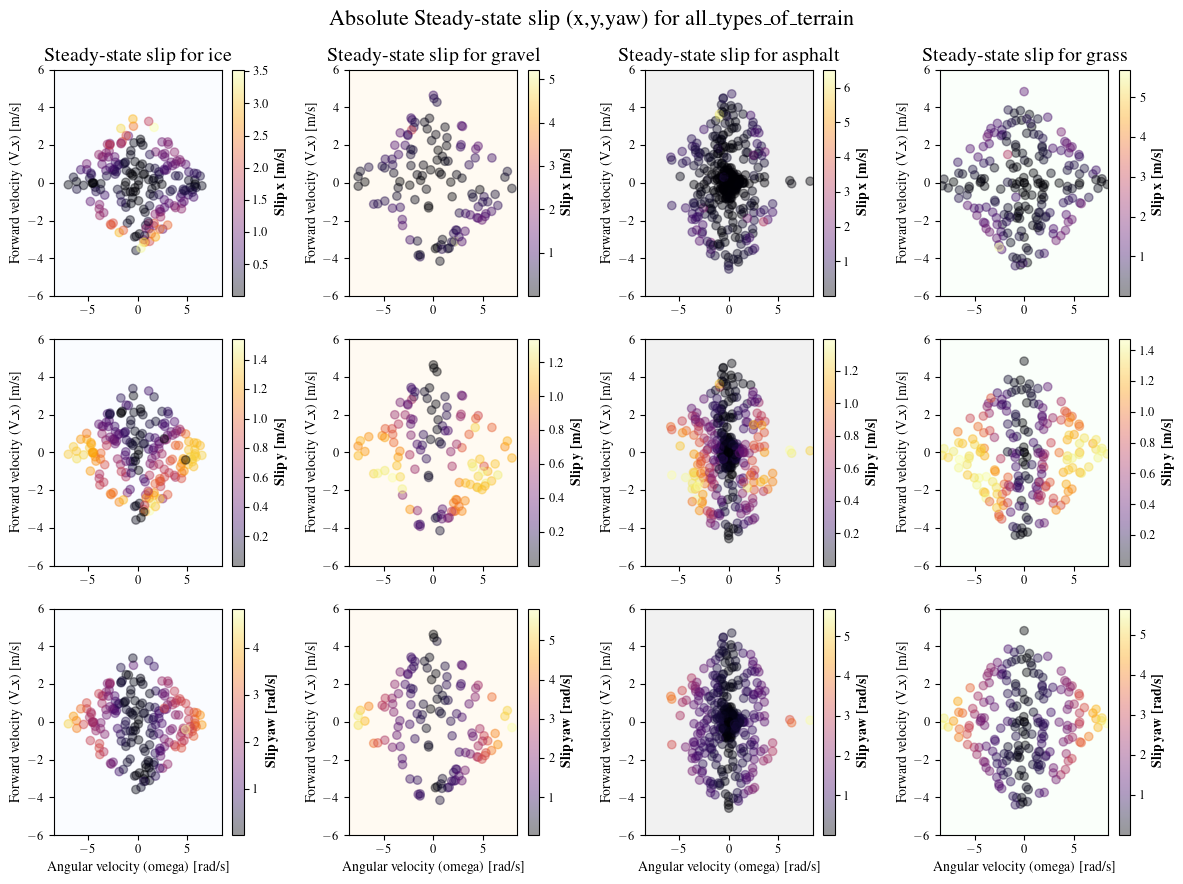

In [13]:
def plot_diamond_graph_slip_heat_map(df_all_terrain,global_cmap = True):
    color_dict = {"asphalt":"lightgrey", "ice":"aliceblue","gravel":"papayawhip","grass":"honeydew"}
    list_terrain = df_all_terrain["terrain"].unique()
    size = len(list_terrain)
    fig, axs = plt.subplots(3,size)

    fig.set_figwidth(3*size)
    fig.set_figheight(3*3)
    alpha_parama= 0.3

    y_lim = 6 # m/s
    x_lim = 8.5 #m/s
    cmap = 'viridis' # 
    norm_slip_yaw = mpl.colors.Normalize(0, vmax=df_all_terrain["slip_body_yaw_ss"].max())

    norm_slip_wheel = mpl.colors.Normalize(0, 0)

    scatter_colored_plot_slip_x = []
    scatter_colored_plot_slip_yaw = []  

    global_cmap = [global_cmap,df_all_combined]
    
    alpha_scatter = 0.4
    
    for i in range(size):  
        terrain = list_terrain[i]
        
        df = df_all_terrain.loc[df_all_terrain["terrain"]==terrain]
        
        labels_xyz  = ["Angular velocity (omega) [rad/s]" , "Forward velocity (V_x) [m/s]",""] 
        column_x_y_z = ["cmd_body_yaw","cmd_body_x", "slip_body_x_ss"]
        show_x_label = False
        #### Slip x 
        if size == 1:
            ax_to_plot = axs[0]
        else:
            ax_to_plot = axs[0,i]
        
        labels_xyz[2] = r"$\textbf{Slip x [m/s]}$"
        scatter_plot_slip(df, column_x_y_z, ax_to_plot, "inferno", color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
       
        ##### Slip y 
        
        column_x_y_z[2] = "slip_body_y_ss"

        if size == 1:
            ax_to_plot = axs[1]
        else:
            ax_to_plot = axs[1,i]
        labels_xyz[2] = r"$\textbf{Slip y [m/s]}$"
        ######### slip y  ####################
        scatter_plot_slip(df,column_x_y_z, ax_to_plot, "inferno",color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
        


        ### Slip yaw 
        column_x_y_z[2] = "slip_body_yaw_ss"
        show_x_label = True
        if size == 1:
            ax_to_plot = axs[2]
        else:
            ax_to_plot = axs[2,i]
        ######### slip y  ####################
        labels_xyz[2] = r"$\textbf{Slip yaw [rad/s]}$"
        scatter_plot_slip(df,column_x_y_z, ax_to_plot, "inferno",color_dict[terrain],y_lim,x_lim,global_cmap,labels_xyz,alpha_scatter,show_x_label)
        

        axs[0][i].set_title(f"Steady-state slip for {terrain}") # (ICP smooth by spline,yaw=imu)
        

        #if not global_cmap:
        #    scatter_colored_plot_slip_yaw.append(axs[2][i].scatter(df["cmd_body_yaw"],df["cmd_body_x"],c = np.abs(df["slip_body_yaw_ss"]),cmap="viridis",alpha=0.2))
        #else:    
        #    scatter_colored_plot_slip_yaw.append(axs[2][i].scatter(df["cmd_body_yaw"],df["cmd_body_x"],c = np.abs(df["slip_body_yaw_ss"]),cmap="viridis",norm=norm_slip_yaw,alpha=0.2))
        #axs[2][i].set_xlabel("Angular velocity (omega) [rad/s]")
        #axs[2][i].set_ylabel("Forward velocity (V_x) [m/s]")
        #cbar = plt.colorbar(scatter_colored_plot_slip_yaw[i], ax=axs[2, i])
        #cbar.set_label('Yaw slip')
        #axs[2][i].set_ylim((-y_lim,y_lim))
        #axs[2][i].set_xlim((-x_lim,x_lim))
        #axs[2][i].set_facecolor(color_dict[terrain])


        #axs[1][i].set_xlabel("Angular velocity (omega) [rad/s]")
        #axs[1][i].set_ylabel("Forward velocity (V_x) [m/s]")
        #cbar1 = plt.colorbar(scatter_colored_plot_slip_yaw[i], ax=axs[1, i])
        #cbar1.set_label('Yaw slip')
        #axs[1][i].set_title(f"Wheels slip {terrain}")
        #wheels_value = 20
        #axs[1][i].set_ylim((-wheels_value,wheels_value))
        #axs[1][i].set_xlim((-wheels_value,wheels_value))
        
        

        #fig.patches .set_facecolor()
        

    l, legends_label = axs[0][0].get_legend_handles_labels()
    
    l2, legends_label_2 = axs[1][0].get_legend_handles_labels()
    #axs[0][-1].set_axis_off()
    #axs[1][-1].set_axis_off()
    
    legends_labels = legends_label+legends_label_2

    
    lines = l+l2
    #axs[0][-1].legend(lines, legends_labels, loc = 'center', bbox_to_anchor = (0, -0.55, 1, 1),
    #            bbox_transform = plt.gcf().transFigure,ncol=3)
    fig.suptitle(f"Absolute Steady-state slip (x,y,yaw) for all_types_of_terrain",fontsize=16)

    #fig.patch.set_facecolor(color_background)
    
    fig.tight_layout()

    print('Note that the yaw angle in the the smooth version is the IMU')



plot_diamond_graph_slip_heat_map(df_all_combined,global_cmap=False)